# Cinema データセット探索

このノートブックでは、Cinema データセットの探索的データ分析（EDA）を行います。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# スタイル設定（フォント設定の前に実行）
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# 日本語フォント設定（自動検出）
japanese_fonts = [
    'MS Gothic',        # Windows
    'Yu Gothic',        # Windows
    'Meiryo',           # Windows
    'Hiragino Sans',    # macOS
    'IPAexGothic',      # Linux
    'Noto Sans CJK JP'  # Linux
]

# 利用可能なフォントを検索
available_fonts = [f.name for f in fm.fontManager.ttflist]
selected_font = None

for font in japanese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = selected_font
    print(f"日本語フォント: {selected_font} を使用します")
else:
    print("警告: 日本語フォントが見つかりませんでした。デフォルトフォントを使用します。")

# マイナス記号が文字化けしないように設定
plt.rcParams['axes.unicode_minus'] = False

print(f"現在のフォント設定: {plt.rcParams['font.family']}")

日本語フォント: MS Gothic を使用します
現在のフォント設定: ['MS Gothic']


## 1. データ読み込み

In [2]:
# Cinema データセットを読み込む
df = pd.read_csv('../data/cinema.csv')

print(f"データ件数: {len(df)} 件")
print(f"特徴量数: {len(df.columns) - 1} 個")
print("\n最初の5行:")
df.head()

データ件数: 100 件
特徴量数: 5 個

最初の5行:


,cinema_id,SNS1,SNS2,actor,original,sales
0,1375,291.0,1044,8808.994029,0,9731
1,1000,363.0,568,10290.709370,1,10210
2,1390,158.0,431,6340.388534,1,8227
3,1499,261.0,578,8250.485081,0,9658
4,1164,209.0,683,10908.539550,0,9286


## 2. データの基本統計

In [3]:
# 基本統計量
df.describe()

,cinema_id,SNS1,SNS2,actor,original,sales
count,100.000000,99.000000,100.000000,99.000000,100.000000,100.0000
mean,1465.310000,370.737374,658.510000,9817.539306,0.500000,9882.4300
std,297.894826,211.925795,323.839232,1446.802508,0.502519,799.2267
min,1000.000000,0.000000,0.000000,5702.796056,0.000000,7869.0000
25%,1212.750000,194.500000,443.250000,8819.109486,0.000000,9314.5000
50%,1455.000000,350.000000,654.000000,9991.717888,0.500000,9965.0000
75%,1739.250000,513.500000,885.750000,10796.866185,1.000000,10440.2500
max,1989.000000,1000.000000,1500.000000,12665.073780,1.000000,11405.0000


## 3. 欠損値の確認

In [4]:
# 欠損値の数を確認
missing_values = df.isnull().sum()
print("欠損値の数:")
print(missing_values)
print(f"\n欠損値の割合:")
print((missing_values / len(df) * 100).round(2))

欠損値の数:
cinema_id    0
SNS1         1
SNS2         0
actor        1
original     0
sales        0
dtype: int64

欠損値の割合:
cinema_id    0.0
SNS1         1.0
SNS2         0.0
actor        1.0
original     0.0
sales        0.0
dtype: float64


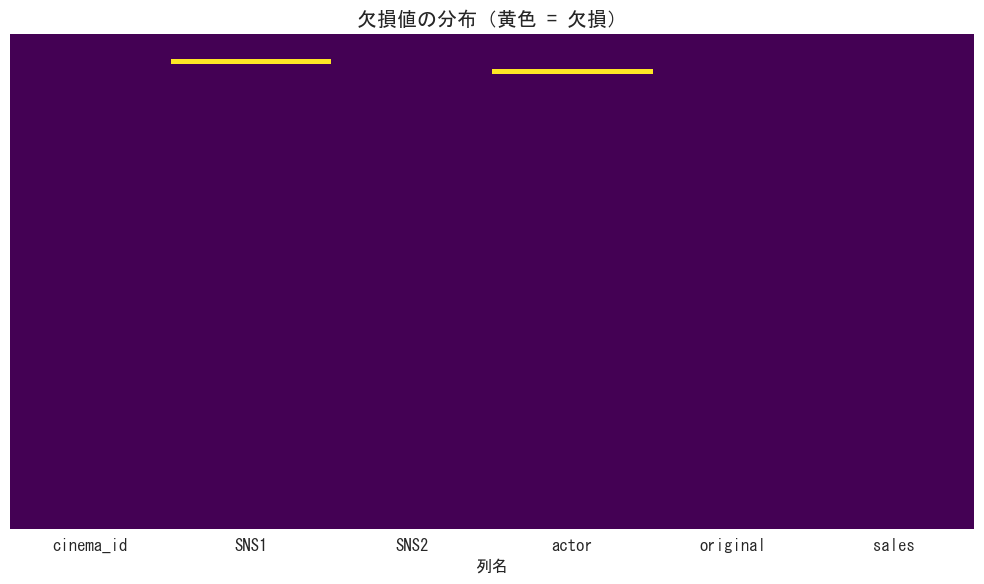

In [5]:
# 欠損値の可視化
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('欠損値の分布（黄色 = 欠損）')
plt.xlabel('列名')
plt.tight_layout()
plt.show()

## 4. 特徴量の分布

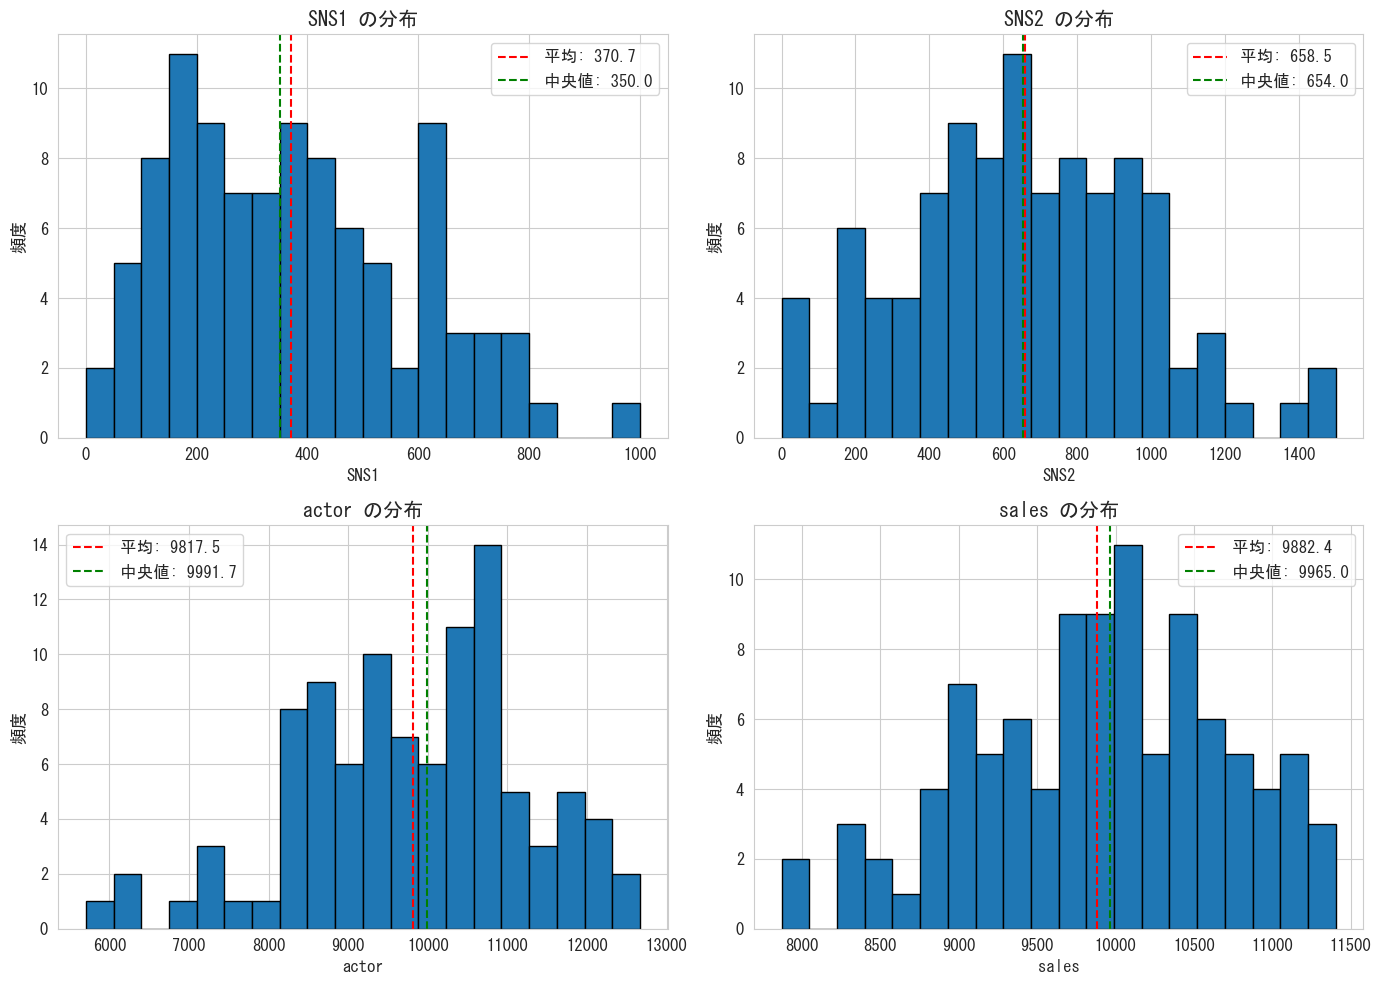

In [6]:
# 数値特徴量のヒストグラム
numeric_features = ['SNS1', 'SNS2', 'actor', 'sales']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(numeric_features):
    ax = axes[i // 2, i % 2]
    df[feature].hist(bins=20, ax=ax, edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('頻度')
    ax.set_title(f'{feature} の分布')
    ax.axvline(df[feature].mean(), color='red', linestyle='--', label=f'平均: {df[feature].mean():.1f}')
    ax.axvline(df[feature].median(), color='green', linestyle='--', label=f'中央値: {df[feature].median():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

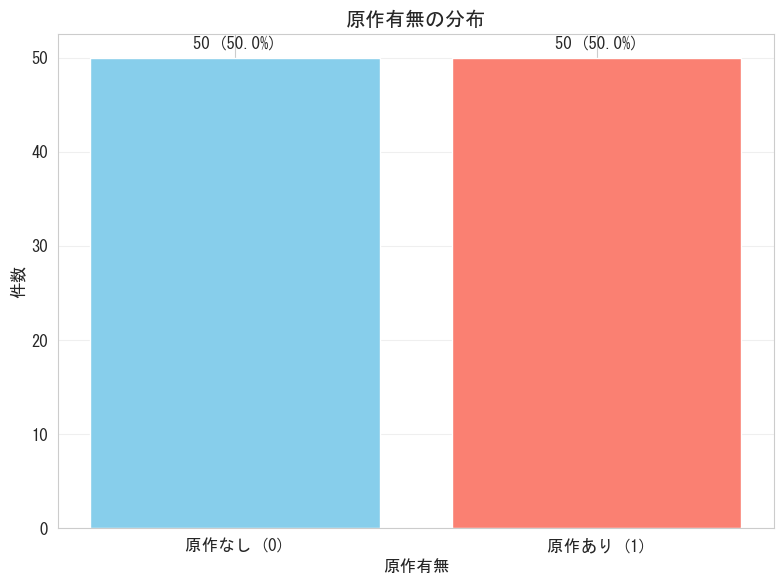

In [7]:
# original（原作有無）の分布
plt.figure(figsize=(8, 6))
original_counts = df['original'].value_counts()
plt.bar(['原作なし (0)', '原作あり (1)'], original_counts.values, color=['skyblue', 'salmon'])
plt.xlabel('原作有無')
plt.ylabel('件数')
plt.title('原作有無の分布')
plt.grid(axis='y', alpha=0.3)

# パーセンテージを表示
for i, (label, value) in enumerate(zip(['原作なし (0)', '原作あり (1)'], original_counts.values)):
    plt.text(i, value + 1, f'{value} ({value/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

## 5. 相関分析

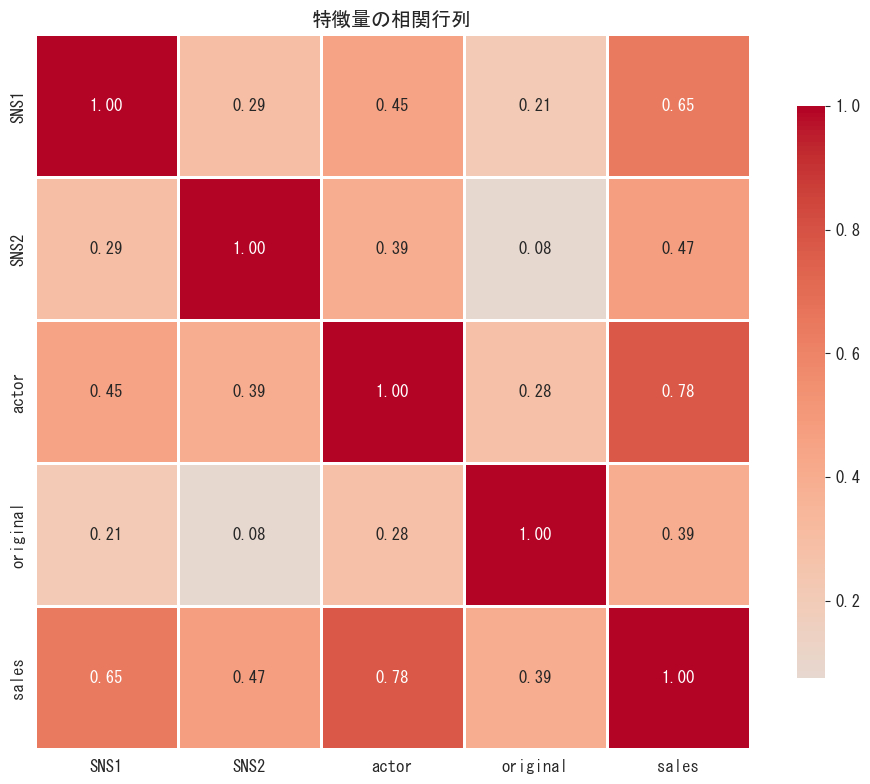

In [8]:
# 相関行列
correlation_matrix = df[['SNS1', 'SNS2', 'actor', 'original', 'sales']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('特徴量の相関行列')
plt.tight_layout()
plt.show()

興行収入 (sales) との相関係数:
actor       0.779344
SNS1        0.645904
SNS2        0.471079
original    0.390118
Name: sales, dtype: float64


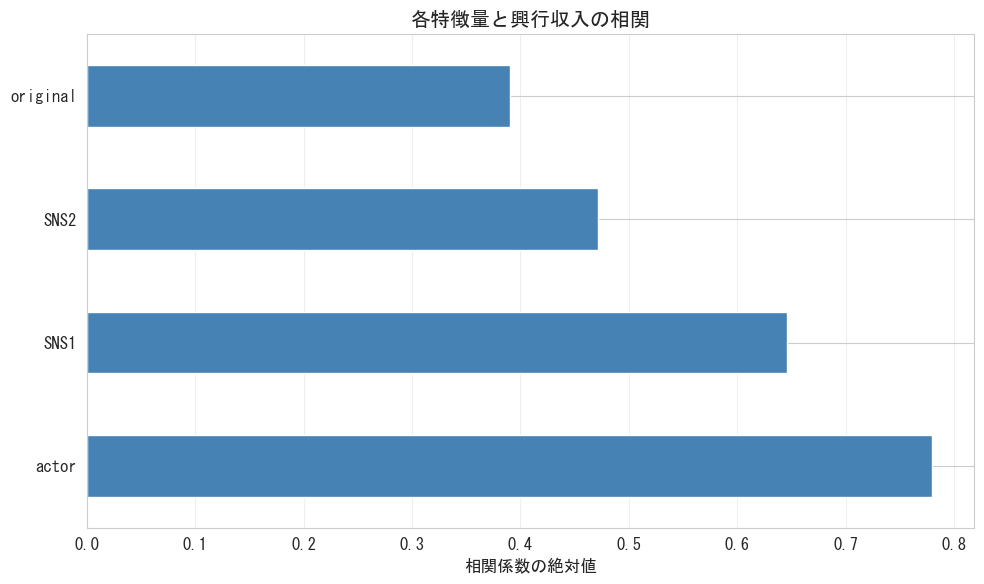

In [9]:
# sales との相関係数（絶対値の大きい順）
sales_correlation = correlation_matrix['sales'].drop('sales').abs().sort_values(ascending=False)
print("興行収入 (sales) との相関係数:")
print(sales_correlation)

plt.figure(figsize=(10, 6))
sales_correlation.plot(kind='barh', color='steelblue')
plt.xlabel('相関係数の絶対値')
plt.title('各特徴量と興行収入の相関')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 特徴量と興行収入の関係

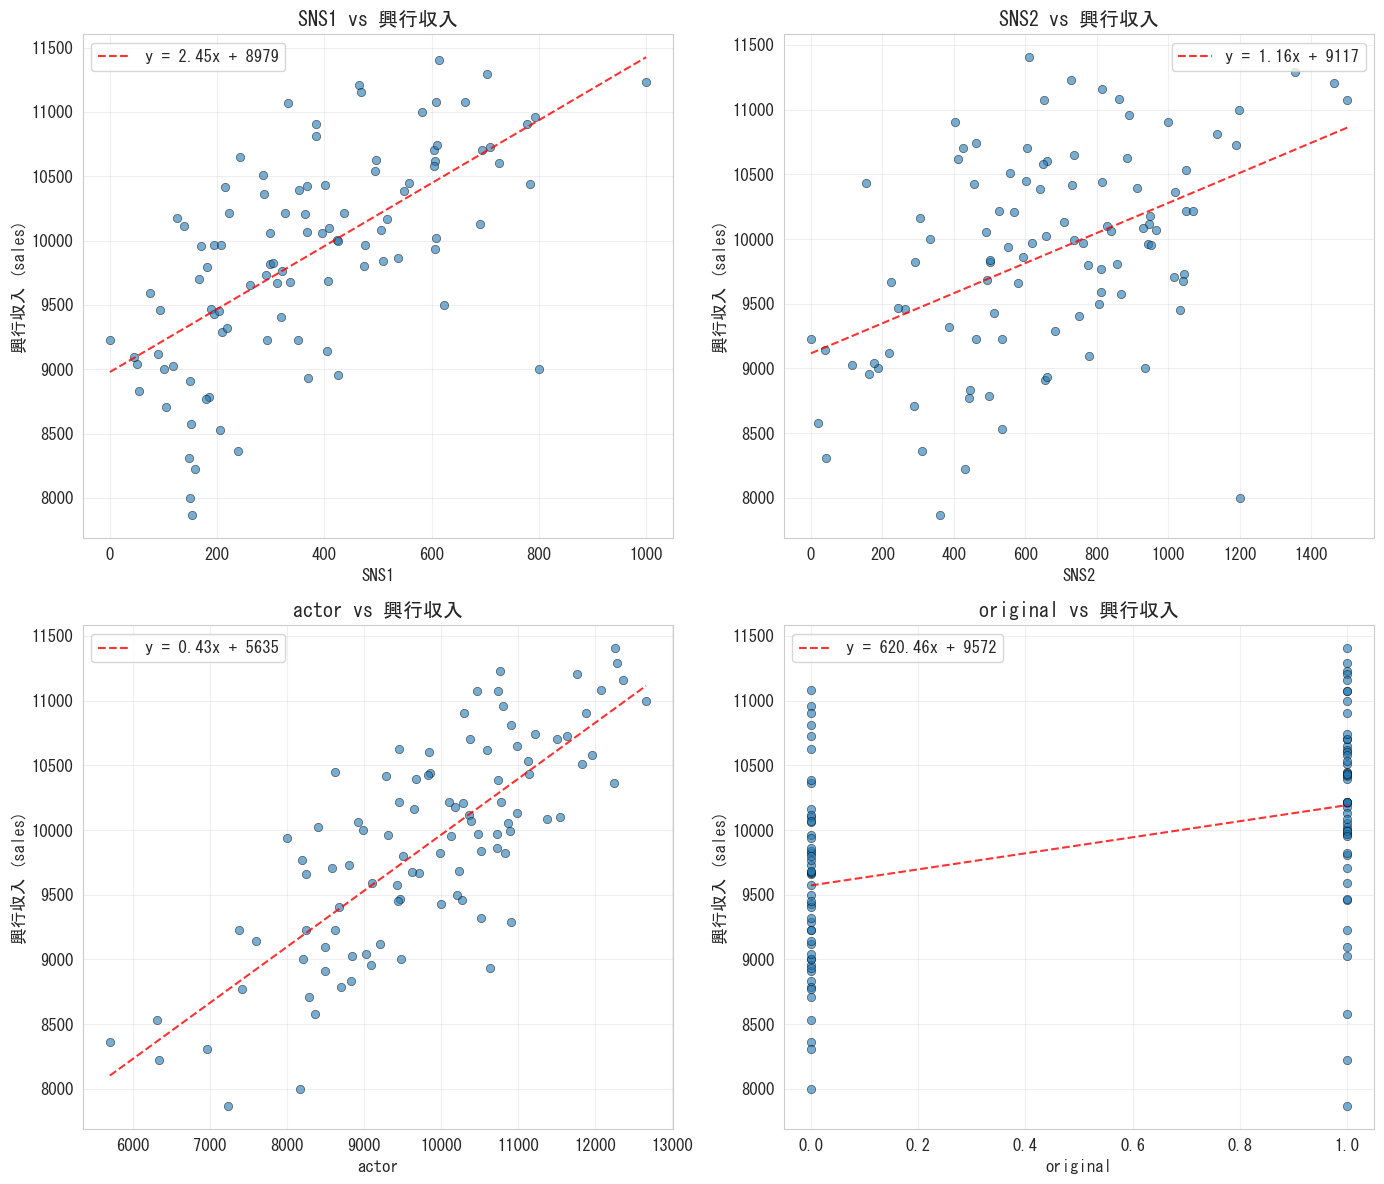

In [10]:
# 散布図: SNS1 vs sales
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

features_to_plot = ['SNS1', 'SNS2', 'actor', 'original']
for i, feature in enumerate(features_to_plot):
    ax = axes[i // 2, i % 2]
    ax.scatter(df[feature], df['sales'], alpha=0.6, edgecolors='black', linewidths=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel('興行収入 (sales)')
    ax.set_title(f'{feature} vs 興行収入')
    ax.grid(True, alpha=0.3)
    
    # 回帰直線を追加（欠損値を除く）
    valid_mask = df[[feature, 'sales']].notna().all(axis=1)
    if valid_mask.sum() > 0:
        z = np.polyfit(df.loc[valid_mask, feature], df.loc[valid_mask, 'sales'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, label=f'y = {z[0]:.2f}x + {z[1]:.0f}')
        ax.legend()

plt.tight_layout()
plt.show()

## 7. 原作有無による興行収入の比較

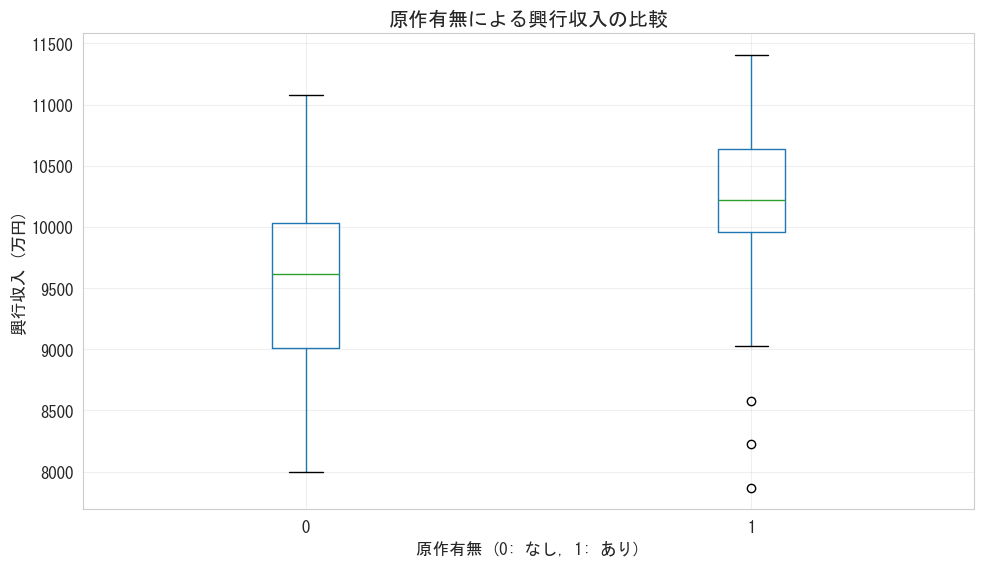


原作有無による興行収入の統計:
          count      mean         std     min      25%      50%       75%  \
original                                                                    
0          50.0   9572.20  720.789845  8000.0  9011.25   9616.0  10035.25   
1          50.0  10192.66  758.031032  7869.0  9959.25  10216.0  10638.25   

              max  
original           
0         11079.0  
1         11405.0  


In [11]:
# 箱ひげ図
plt.figure(figsize=(10, 6))
df.boxplot(column='sales', by='original', ax=plt.gca())
plt.xlabel('原作有無 (0: なし, 1: あり)')
plt.ylabel('興行収入 (万円)')
plt.title('原作有無による興行収入の比較')
plt.suptitle('')  # デフォルトのタイトルを削除
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 統計量の比較
print("\n原作有無による興行収入の統計:")
print(df.groupby('original')['sales'].describe())

## 8. まとめ

### 主な観察結果:

1. **データの特徴**:
   - 100件のデータ（比較的小規模）
   - SNS1, SNS2, actor に欠損値あり
   - 興行収入は約8,000〜12,000万円の範囲

2. **相関関係**:
   - SNS1, SNS2 と興行収入に正の相関
   - actor（俳優の露出度）も興行収入に影響
   - original（原作有無）も一定の相関あり

3. **欠損値**:
   - 3つの特徴量に欠損値が存在
   - 線形回帰モデルでは平均値で補完

4. **予測の見通し**:
   - 線形回帰モデルで R² ≈ 0.79（訓練データ）を達成
   - SNS データが主要な予測要因
   - 検証データでは若干の過学習（R² ≈ 0.54）